In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import ast
import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from IPython.display import display as ipy_display
from PIL import Image

In [ ]:
BASE_DIR   = "/content/drive/MyDrive/CAMES/data_collection_training"
PID        = "P19"

session_dir = os.path.join(BASE_DIR, PID, f"{PID}_session1")
gaze_path   = os.path.join(session_dir, f"eye_{PID}", "gaze_marked.csv")
vid_file    = os.path.join(session_dir, f"{PID}screen_session1.mp4")

In [ ]:
# Filtering — set TASK_LABEL to None for full session, or e.g. "task1_5_2"
TASK_LABEL       = "task1_5_2"   # None = full session
EXPLORATION_ONLY = False         # True = exploration periods only

# Background image — timestamp in seconds to grab from screen recording
IMAGE_TIMESTAMP = 400

# Heatmap settings
W, H        = 640, 360
BLUR_SIGMA  = 10
FLIP_Y      = False
NORM_MODE   = "log"    # "log" or "global"
ALPHA       = 0.6      # opacity of heatmap overlay

In [ ]:
#Load gaze data
df = pd.read_csv(gaze_path, low_memory=False)

TASK_OFFSET_S = 200  # seconds into the task to grab the frame

if TASK_LABEL is not None:
    session_start_unix = pd.read_csv(gaze_path, low_memory=False)["Timestamp Unix"].min()
    task_start_unix    = df[df["task_label"] == TASK_LABEL]["Timestamp Unix"].min()
    IMAGE_TIMESTAMP    = float(task_start_unix - session_start_unix) + TASK_OFFSET_S
    print(f"Grabbing frame at {IMAGE_TIMESTAMP:.1f}s into the recording")
else:
    IMAGE_TIMESTAMP = 30  # fallback for full session

#Filter
if TASK_LABEL is not None:
    df = df[df["task_label"] == TASK_LABEL].copy()
    print(f"Filtered to task: {TASK_LABEL} — {len(df)} samples")

if EXPLORATION_ONLY:
    df = df[df["in_exploration"] == True].copy()
    print(f"Filtered to exploration only — {len(df)} samples")

if not TASK_LABEL and not EXPLORATION_ONLY:
    print(f"Full session — {len(df)} samples")

Grabbing frame at 1081.4s into the recording
Filtered to task: task1_5_2 — 56961 samples


In [ ]:
#Parse XY coordinates
def parse_xy(val):
    try:
        if pd.isna(val):
            return np.nan, np.nan
        x, y = ast.literal_eval(val)
        return float(x), float(y)
    except Exception:
        return np.nan, np.nan

df[["lx", "ly"]] = df["left_gaze_point_on_display_area"].apply(
    lambda v: pd.Series(parse_xy(v))
)
df[["rx", "ry"]] = df["right_gaze_point_on_display_area"].apply(
    lambda v: pd.Series(parse_xy(v))
)

x = df[["lx", "rx"]].mean(axis=1, skipna=True)
y = df[["ly", "ry"]].mean(axis=1, skipna=True)

valid = x.notna() & y.notna() & x.between(0, 1) & y.between(0, 1)
x = x[valid].to_numpy()
y = y[valid].to_numpy()
print(f"Valid gaze samples: {len(x)}")

if FLIP_Y:
    y = 1.0 - y

Valid gaze samples: 51100


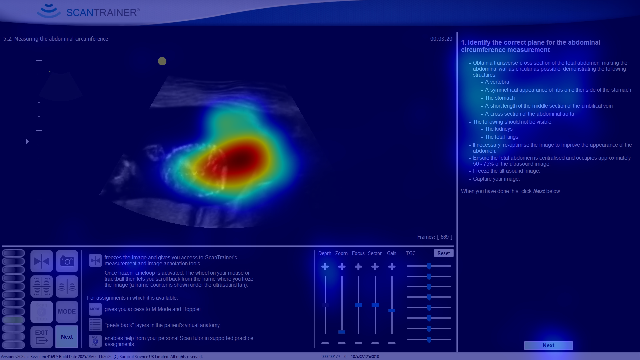

In [ ]:
#Build heatmap
heat, _, _ = np.histogram2d(y, x, bins=[H, W], range=[[0, 1], [0, 1]])
heat = heat.astype(np.float32)
disp = cv2.GaussianBlur(heat, (0, 0), BLUR_SIGMA, BLUR_SIGMA)

if NORM_MODE == "global":
    mx = float(disp.max()) if disp.max() > 0 else 1.0
    u8 = np.clip((disp / mx) * 255.0, 0, 255).astype(np.uint8)
else:
    disp = np.log1p(disp)
    mx = float(disp.max()) if disp.max() > 0 else 1.0
    u8 = np.clip((disp / mx) * 255.0, 0, 255).astype(np.uint8)

cap = cv2.VideoCapture(vid_file)
fps = cap.get(cv2.CAP_PROP_FPS)
cap.set(cv2.CAP_PROP_POS_FRAMES, fps * IMAGE_TIMESTAMP)
ret, image = cap.read()
cap.release()

if ret:
    image = cv2.resize(image, (W, H))
else:
    print("Could not read video frame — using black background")
    image = np.zeros((H, W, 3), dtype=np.uint8)

#Overlay and display
heatmap     = cv2.applyColorMap(u8, cv2.COLORMAP_JET)
overlay     = cv2.addWeighted(heatmap, ALPHA, image, 1 - ALPHA, 0)
overlay_rgb = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)


title_parts = [PID]
if TASK_LABEL:
    title_parts.append(TASK_LABEL)
else:
    title_parts.append("full session")
if EXPLORATION_ONLY:
    title_parts.append("exploration only")
title = " — ".join(title_parts)

img_pil = Image.fromarray(overlay_rgb)
ipy_display(img_pil)


In [ ]:
SAVE = True   # set to True and run again to save
if SAVE:
    out_path = os.path.join(session_dir, f"eye_{PID}", f"heatmap_{title.replace(' — ', '_').replace(' ', '_')}.png")
    overlay_bgr = cv2.cvtColor(overlay_rgb, cv2.COLOR_RGB2BGR)
    cv2.imwrite(out_path, overlay_bgr)
    print(f"Saved → {out_path}")

Saved → /content/drive/MyDrive/CAMES/data_collection_training/P19/P19_session1/eye_P19/heatmap_P19_task1_5_2.png
